##  **A. Enfoque de validación** 

In [48]:
import pandas as pd
#no se si hicieron otra "respondieron" definitiva, agarré (generé) la primera que hicieron el tp1 que tiene la var. pobre.
#tiene 70% pobres...
#no use la respondieron original porque no tiene la variable pobre
respondieron=pd.read_excel("/Users/solgoren/Desktop/UdeSA/Ciencia de datos/TP1/respondieron_este.xlsx")
print(respondieron.head())
#hice pip install sklearn en la terminal para que ande sklearn
print(respondieron.columns)


   ano4  ch04  ch06  ch07  ch08  nivel_ed  estado  cat_inac         ipcf  ch10  ch03  ch14  ch15  pp02e  pp02i  ch09    codusu   sexo  nivel ed  adulto_equiv  ad_equiv_hogar  ingreso_necesario  pobre
0  2005     1     4     5   1.0         7     4.0         5   280.000000   1.0     3   1.0   1.0    NaN    NaN     2  125082    Varón       NaN          0.55            0.55           112.7885      0
1  2005     2     1     5  12.0         7     4.0         5   400.000000   NaN     3   NaN   1.0    NaN    NaN     3  125409    Mujer       NaN          0.37            0.37            75.8759      0
2  2005     2    78     4   1.0         6     3.0         1  3200.000000   2.0     1   NaN   1.0    NaN    2.0     1  126610    Mujer       NaN          0.63            0.63           129.1941      0
3  2005     1    16     5   1.0         3     3.0         3   435.000000   1.0     3   2.0   1.0    NaN    2.0     1  126653    Varón       NaN          1.03            1.03           211.2221      0


In [49]:
norespondieron=pd.read_excel("/Users/solgoren/Desktop/UdeSA/Ciencia de datos/TP1/norespondieron.xlsx")
#para el norespondieron agarré el archivo exportado del tp1 directamente

In [50]:
#chequando los valores
print(respondieron["pobre"].unique())
pobre_percentages = respondieron['pobre'].value_counts(normalize=True) * 100

# Print the resulting Series
print(pobre_percentages)


[0 1]
pobre
1    70.566559
0    29.433441
Name: proportion, dtype: float64


In [51]:
import sklearn 
#create a train and test base using train_test_split. make the train 70% and test 30%. use random state instance: 444


from sklearn.model_selection import train_test_split

X = respondieron.drop(columns=['pobre','ipcf']) #itf no esta en la tabla. dropee ipcf como pide el ej.

y = respondieron['pobre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (12157, 21)
Shape of X_test: (5211, 21)
Shape of y_train: (12157,)
Shape of y_test: (5211,)


In [52]:
from sklearn.model_selection import train_test_split

YEAR_COL = "ano4"
years = sorted(respondieron[YEAR_COL].dropna().unique())

splits = {}

for year in years:
    # Filtrar cada año
    dfy = respondieron[respondieron[YEAR_COL] == year].copy()

    # Variable dependiente
    y = dfy["pobre"].copy()

    # Variables independientes (sin 'pobre', 'ingreso' ni 'ipcf')
    X = dfy.drop(columns=["pobre", "ingreso", "ipcf"], errors="ignore")

    # División 70/30 con semilla 444
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=y
    )

    # 💡 AGREGAR AQUÍ la columna de unos (intercepto)
    Xtr = Xtr.assign(intercepto=1)
    Xte = Xte.assign(intercepto=1)

    # Guardar los splits por año
    splits[year] = {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}

# Verificación
print("Años con split:", years)
for y in years:
    Xt, Xs = splits[y]["X_train"], splits[y]["X_test"]
    print(f"{y} -> X_train: {Xt.shape}, X_test: {Xs.shape}, intercepto incluido: {'intercepto' in Xt.columns}")


Años con split: [np.int64(2005), np.int64(2025)]
2005 -> X_train: (5619, 22), X_test: (2409, 22), intercepto incluido: True
2025 -> X_train: (6538, 22), X_test: (2802, 22), intercepto incluido: True


### Ejercicio 1

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1) Cargo la base y armo splits por año (70/30, semilla 444)

YEAR_COL = "ano4"

splits = {}
years = sorted(respondieron[YEAR_COL].dropna().unique())
for year in years:
    dfy = respondieron[respondieron[YEAR_COL] == year].copy()
    y = dfy["pobre"].copy()
    X = dfy.drop(columns=["pobre", "ingreso", "ipcf"], errors="ignore")

    strat = y if y.nunique() > 1 else None
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=strat
    )
    Xtr = Xtr.assign(intercepto=1)
    Xte = Xte.assign(intercepto=1)
    splits[year] = {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}

# 2) Elijo el año a reportar (podés cambiarlo a 2005 si querés)
año = max(splits.keys())
X_train = splits[año]["X_train"].copy()
X_test  = splits[año]["X_test"].copy()
y_train = splits[año]["y_train"].copy()

# 3) Selección objetiva de X: numéricas, excluyendo el intercepto; priorizo las más asociadas a y (|corr|)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "intercepto"]

corrs = {}
for c in num_cols:
    x = X_train[c].copy()
    if x.isna().all():
        corrs[c] = np.nan
    else:
        corrs[c] = np.corrcoef(x.fillna(x.median()), y_train)[0,1]
corrs_s = pd.Series(corrs).abs().sort_values(ascending=False)

# ajustá la cantidad si querés (ej.: 10–15 variables que limpiaron previamente)
variables_seleccionadas = corrs_s.dropna().head(12).index.tolist()

# 4) Tabla de diferencias de medias
medias_train = X_train[variables_seleccionadas].mean()
medias_test  = X_test[variables_seleccionadas].mean()

tabla = pd.DataFrame({
    "Media_train": medias_train,
    "Media_test": medias_test
})
tabla["Diferencia_media"] = tabla["Media_train"] - tabla["Media_test"]
tabla["Dif_rel_%"] = (tabla["Diferencia_media"] / tabla["Media_train"].replace(0, np.nan)).abs() * 100

# 5) Contraste de medias (Welch)
try:
    from scipy import stats
    pvals = {}
    for c in variables_seleccionadas:
        a = X_train[c].dropna().values
        b = X_test[c].dropna().values
        pvals[c] = stats.ttest_ind(a, b, equal_var=False).pvalue if len(a)>1 and len(b)>1 else np.nan
    tabla["p_value"] = pd.Series(pvals)
    tabla["signif_0.05"] = tabla["p_value"] < 0.05
except Exception:
    tabla["p_value"] = np.nan
    tabla["signif_0.05"] = np.nan

tabla_dif = tabla.sort_values("Dif_rel_%", ascending=False).round(4)
print(f"Diferencia de medias entre entrenamiento y testeo – Año {año}")
display(tabla_dif)

Diferencia de medias entre entrenamiento y testeo – Año 2025


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Media_train,Media_test,Diferencia_media,Dif_rel_%,p_value,signif_0.05
cat_inac,1.749300e+00,1.708400e+00,0.0409,2.3374,0.3465,False
ch08,2.107400e+00,2.063900e+00,0.0435,2.0637,0.2740,False
ch15,1.408200e+00,1.386500e+00,0.0217,1.5423,0.2163,False
ch07,3.437700e+00,3.395400e+00,0.0423,1.2309,0.2593,False
ch06,3.718770e+01,3.676620e+01,0.4214,1.1333,0.4060,False
nivel_ed,3.719500e+00,3.678400e+00,0.0410,1.1034,0.3077,False
ch09,1.085700e+00,1.076400e+00,0.0093,0.8547,0.1928,False
ch10,1.726300e+00,1.713400e+00,0.0129,0.7475,0.2455,False
ingreso_necesario,1.018420e+06,1.021849e+06,-3428.7242,0.3367,0.7702,False
ad_equiv_hogar,2.788800e+00,2.798200e+00,-0.0094,0.3367,0.7702,False


### Ejercicio 2

In [54]:
# Asumiendo que la columna se llama 'ano4'
respondieron_2005 = respondieron[respondieron["ano4"] == 2005].copy()
respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

norespondieron_2005 = norespondieron[norespondieron["ano4"] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron["ano4"] == 2025].copy()

# Mostrar la cantidad de filas para verificar
print("Respondieron 2005:", respondieron_2005.shape)
print("Respondieron 2025:", respondieron_2025.shape)
print("No respondieron 2005:", norespondieron_2005.shape)
print("No respondieron 2025:", norespondieron_2025.shape)

Respondieron 2005: (8028, 23)
Respondieron 2025: (9340, 23)
No respondieron 2005: (107, 18)
No respondieron 2025: (4461, 18)


## **B. Modelo de Regresion Logistica**

### Ejercicio 3: Estimación y Efectos Marginales

In [55]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Año de trabajo
año = 2025
X_train = splits[año]["X_train"].copy()
y_train = splits[año]["y_train"].copy()

# Variables del modelo (ajustá a tus limpias del TP)
variables_modelo = [
    'ch06','ch07','ch08','ch09','ch10',
    'nivel_ed','cat_inac','ad_equiv_hogar'
]
variables_modelo = [v for v in variables_modelo if v in X_train.columns]

# Matriz X + intercepto (ya existe, por las dudas lo tomo explícito)
X = X_train[variables_modelo + ['intercepto']].copy()

# 1) Limpiar infinitos y NAs (requisito de statsmodels)
X = X.replace([np.inf, -np.inf], np.nan)
dfm = pd.concat([y_train.rename('pobre'), X], axis=1)

# Opción 1: eliminar filas con NA en cualquiera de las columnas del modelo
dfm = dfm.dropna(axis=0)

y = dfm['pobre'].astype(int)
X = dfm.drop(columns='pobre')

# 2) Estimar Logit
logit = sm.Logit(y, X)
res = logit.fit()

# 3) Tabla de coeficientes, errores estándar y odds ratios
tabla_logit = pd.DataFrame({
    'Coeficiente': res.params,
    'Error_Estandar': res.bse,
    'Odds_Ratio': np.exp(res.params)
}).round(4)

print("Resultados Logit — Año", año)
display(tabla_logit)

# 4) Efectos marginales promedio (AME)
mfx = res.get_margeff(at='overall')          # AME
tabla_mfx = mfx.summary_frame()               # columnas: dy/dx, Std. Err., z, P>|z|, [0.025, 0.975]
tabla_mfx = tabla_mfx.rename(columns={'dy/dx':'AME'}).round(4)

print("Efectos marginales promedio (AME) — Año", año)
display(tabla_mfx)

# (Opcional) exportar a CSV
# tabla_logit.to_csv("logit_coeficientes_{}.csv".format(año), index=True)
# tabla_mfx.to_csv("logit_marginales_{}.csv".format(año), index=True)



Optimization terminated successfully.
         Current function value: 0.277419
         Iterations 8
Resultados Logit — Año 2025


,Coeficiente,Error_Estandar,Odds_Ratio
ch06,-0.0014,0.0027,0.9986
ch07,0.0334,0.0307,1.0340
ch08,0.0847,0.0224,1.0884
ch09,0.7281,0.2831,2.0712
ch10,0.1841,0.1373,1.2021
nivel_ed,-0.3599,0.0289,0.6977
cat_inac,0.2110,0.0280,1.2349
ad_equiv_hogar,2.4020,0.0796,11.0450
intercepto,-3.9793,0.4231,0.0187


Efectos marginales promedio (AME) — Año 2025


,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
ch06,-0.0001,0.0002,-0.5180,0.6045,-0.0006,0.0003
ch07,0.0029,0.0027,1.0873,0.2769,-0.0024,0.0082
ch08,0.0075,0.0020,3.7962,0.0001,0.0036,0.0113
ch09,0.0641,0.0248,2.5779,0.0099,0.0154,0.1128
ch10,0.0162,0.0121,1.3418,0.1797,-0.0075,0.0398
nivel_ed,-0.0317,0.0024,-13.2439,0.0000,-0.0363,-0.0270
cat_inac,0.0186,0.0024,7.7021,0.0000,0.0138,0.0233
ad_equiv_hogar,0.2113,0.0042,49.9806,0.0000,0.2030,0.2196


In [56]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Año de trabajo
año = 2025
X_train = splits[año]["X_train"].copy()
y_train = splits[año]["y_train"].copy()

# --- 1) Variables seleccionadas (como antes, sin las de ingreso) ---
variables_modelo = [
    'ch06','ch07','ch08','ch09','ch10',
    'nivel_ed','cat_inac','ad_equiv_hogar'
]
variables_modelo = [v for v in variables_modelo if v in X_train.columns]

# --- 2) Matriz X e imputación básica ---
X = X_train[variables_modelo].copy()

# Si hay NaN o infinitos, los limpio
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=0)
y = y_train.loc[X.index].astype(int)

# --- 3) Generar dummies para variables categóricas ---
# Esto convierte columnas tipo texto o con pocos valores en dummies (0/1)
X_dum = pd.get_dummies(X, drop_first=True)

# --- 4) Agregar intercepto ---
X_dum = sm.add_constant(X_dum, has_constant='add')

# --- 5) Estimar modelo Logit ---
logit = sm.Logit(y, X_dum)
res = logit.fit()

# --- 6) Tabla de resultados (coef, error estándar, odds ratios) ---
tabla_logit = pd.DataFrame({
    'Coeficiente': res.params,
    'Error_Estandar': res.bse,
    'Odds_Ratio': np.exp(res.params)
}).round(4)

print(f"Resultados Logit — Año {año}")
display(tabla_logit)

# --- 7) Efectos marginales promedio (AME) ---
mfx = res.get_margeff(at='overall')
tabla_mfx = mfx.summary_frame().rename(columns={'dy/dx':'AME'}).round(4)

print(f"Efectos marginales promedio (AME) — Año {año}")
display(tabla_mfx)


Optimization terminated successfully.
         Current function value: 0.277419
         Iterations 8
Resultados Logit — Año 2025


,Coeficiente,Error_Estandar,Odds_Ratio
const,-3.9793,0.4231,0.0187
ch06,-0.0014,0.0027,0.9986
ch07,0.0334,0.0307,1.0340
ch08,0.0847,0.0224,1.0884
ch09,0.7281,0.2831,2.0712
ch10,0.1841,0.1373,1.2021
nivel_ed,-0.3599,0.0289,0.6977
cat_inac,0.2110,0.0280,1.2349
ad_equiv_hogar,2.4020,0.0796,11.0450


Efectos marginales promedio (AME) — Año 2025


,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
ch06,-0.0001,0.0002,-0.5180,0.6045,-0.0006,0.0003
ch07,0.0029,0.0027,1.0873,0.2769,-0.0024,0.0082
ch08,0.0075,0.0020,3.7962,0.0001,0.0036,0.0113
ch09,0.0641,0.0248,2.5779,0.0099,0.0154,0.1128
ch10,0.0162,0.0121,1.3418,0.1797,-0.0075,0.0398
nivel_ed,-0.0317,0.0024,-13.2439,0.0000,-0.0363,-0.0270
cat_inac,0.0186,0.0024,7.7021,0.0000,0.0138,0.0233
ad_equiv_hogar,0.2113,0.0042,49.9806,0.0000,0.2030,0.2196


### Ejercicio 4: Visualización

/var/folders/wm/b3lgksk50dsd556s53_mhkwr0000gn/T/ipykernel_68704/587151153.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


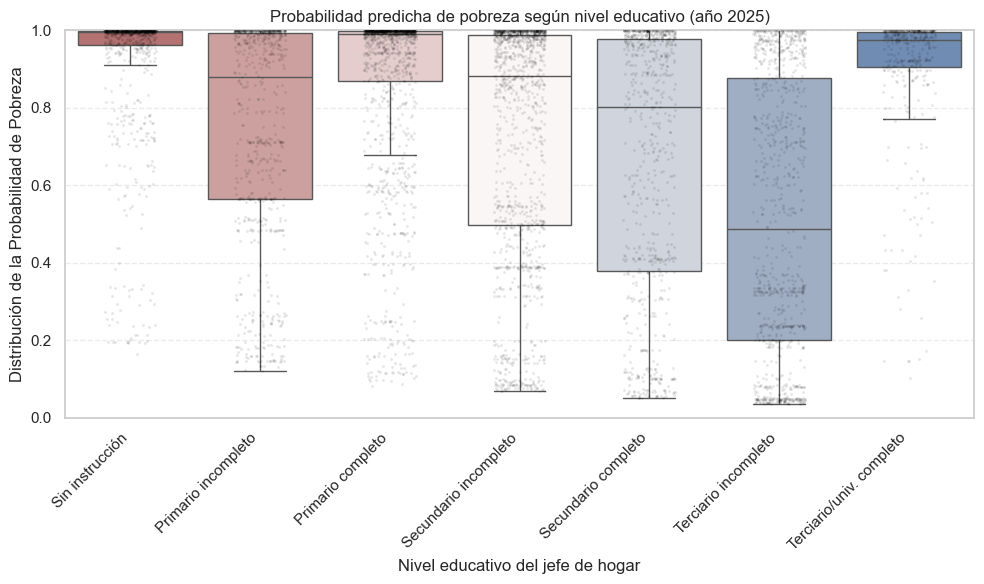

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm  # <- para add_constant

# Año y variable a graficar
año = 2025
variable = 'nivel_ed'

# === preparar X_train con las MISMAS dummies que usó el Logit ===
X_train_raw = splits[año]["X_train"].copy()

# quitar ingresos/intercepto por las dudas
cols_drop = [c for c in X_train_raw.columns
             if c.lower() in ["ipcf", "ingreso", "itf", "intercepto"] or "ingreso" in c.lower()]
X_base = X_train_raw.drop(columns=cols_drop, errors="ignore")

# imputación mínima antes de dummies
X_num = X_base.select_dtypes(include=np.number).copy().fillna(X_base.select_dtypes(include=np.number).median())
X_cat = X_base.select_dtypes(exclude=np.number).copy()
if not X_cat.empty:
    X_cat = X_cat.fillna(X_cat.mode().iloc[0])

# dummies (drop_first=True como en entrenamiento)
X_dum = pd.get_dummies(pd.concat([X_num, X_cat], axis=1), drop_first=True)

# alinear columnas a las del modelo (res)
cols_model = [c for c in res.params.index if c.lower() not in ["const","intercept","intercepto"]]
X_aligned = X_dum.reindex(columns=cols_model, fill_value=0)
X_aligned = sm.add_constant(X_aligned, has_constant='add')

# probabilidad predicha
prob_pred = res.predict(X_aligned)

# DataFrame para graficar
df_plot = pd.DataFrame({
    variable: X_train_raw[variable],
    'Prob_Pobre': prob_pred
}).dropna(subset=[variable])

# Etiquetas del nivel educativo
etiquetas_nivel = {
    1: "Sin instrucción",
    2: "Primario incompleto",
    3: "Primario completo",
    4: "Secundario incompleto",
    5: "Secundario completo",
    6: "Terciario incompleto",
    7: "Terciario/univ. completo"
}

# columnas categóricas para el eje X
df_plot['Nivel Educativo'] = df_plot[variable].map(etiquetas_nivel)
category_order = list(etiquetas_nivel.values())

# --- Gráfico ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    palette='vlag_r',
    showfliers=False
)
sns.stripplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    color='black',
    alpha=0.1,
    jitter=0.2,
    s=2
)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nivel educativo del jefe de hogar")
plt.ylabel("Distribución de la Probabilidad de Pobreza")
plt.title(f'Probabilidad predicha de pobreza según nivel educativo (año {año})')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

/var/folders/wm/b3lgksk50dsd556s53_mhkwr0000gn/T/ipykernel_68704/2135557504.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


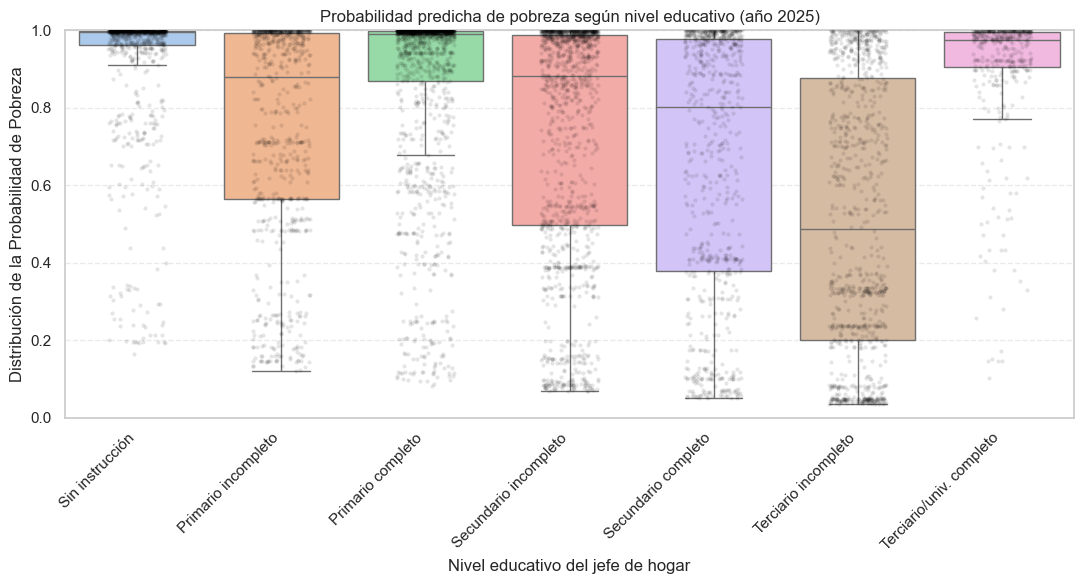

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.api as sm

# Año y variable a graficar
año = 2025
variable = 'nivel_ed'

# === preparar X_train con las MISMAS dummies que usó el Logit ===
X_train_raw = splits[año]["X_train"].copy()

cols_drop = [c for c in X_train_raw.columns
             if c.lower() in ["ipcf", "ingreso", "itf", "intercepto"] or "ingreso" in c.lower()]
X_base = X_train_raw.drop(columns=cols_drop, errors="ignore")

X_num = X_base.select_dtypes(include=np.number).copy().fillna(X_base.select_dtypes(include=np.number).median())
X_cat = X_base.select_dtypes(exclude=np.number).copy()
if not X_cat.empty:
    X_cat = X_cat.fillna(X_cat.mode().iloc[0])

X_dum = pd.get_dummies(pd.concat([X_num, X_cat], axis=1), drop_first=True)

cols_model = [c for c in res.params.index if c.lower() not in ["const","intercept","intercepto"]]
X_aligned = X_dum.reindex(columns=cols_model, fill_value=0)
X_aligned = sm.add_constant(X_aligned, has_constant='add')

prob_pred = res.predict(X_aligned)

# DataFrame para graficar
df_plot = pd.DataFrame({
    variable: X_train_raw[variable],
    'Prob_Pobre': prob_pred
}).dropna(subset=[variable])

# Etiquetas del nivel educativo
etiquetas_nivel = {
    1: "Sin instrucción",
    2: "Primario incompleto",
    3: "Primario completo",
    4: "Secundario incompleto",
    5: "Secundario completo",
    6: "Terciario incompleto",
    7: "Terciario/univ. completo"
}
df_plot['Nivel Educativo'] = df_plot[variable].map(etiquetas_nivel)
category_order = list(etiquetas_nivel.values())

# --- Gráfico ---
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    showfliers=False,
    palette='pastel'
)
sns.stripplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    alpha=0.1,
    s=3,
    jitter=0.2,
    color='black'
)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nivel educativo del jefe de hogar")
plt.ylabel("Distribución de la Probabilidad de Pobreza")
plt.title(f'Probabilidad predicha de pobreza según nivel educativo (año {año})')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## **C. Método de Vecinos Cercanos (KNN)**

### 5. Estimación

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

año = 2025
Xtr = splits[año]["X_train"].drop(columns=["intercepto"], errors="ignore").copy()
ytr = splits[año]["y_train"].copy()
Xte = splits[año]["X_test"].drop(columns=["intercepto"], errors="ignore").copy()
yte = splits[año]["y_test"].copy()

# --- 1) Reclasificar columnas object: numéricas "disfrazadas" vs texto real ---
obj_cols = Xtr.select_dtypes(include="object").columns.tolist()

num_like, cat_cols = [], []
for c in obj_cols:
    s = pd.to_numeric(pd.concat([Xtr[c], Xte[c]], axis=0), errors="coerce")
    # si al menos 90% se puede convertir a número, la tratamos como numérica
    if s.notna().mean() >= 0.9:
        # convertir en ambos sets
        Xtr[c] = pd.to_numeric(Xtr[c], errors="coerce")
        Xte[c] = pd.to_numeric(Xte[c], errors="coerce")
        num_like.append(c)
    else:
        cat_cols.append(c)

num_cols = Xtr.select_dtypes(include=[np.number]).columns.tolist()
# asegurar que no quede ninguna numérica en cat
cat_cols = [c for c in cat_cols if c not in num_cols]

# Opcional: descartar posibles IDs de cardinalidad altísima (evita matrices gigantes)
high_card = [c for c in cat_cols if Xtr[c].nunique() > 0.5 * len(Xtr)]
cat_cols = [c for c in cat_cols if c not in high_card]

# --- 2) Preprocesamiento ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# --- 3) KNN con K = 1, 5, 10 ---
resultados = []
for k in [1, 5, 10]:
    clf = Pipeline(steps=[("prep", preprocess),
                         ("knn", KNeighborsClassifier(n_neighbors=k))])
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    resultados.append({"K": k, "Accuracy_test": accuracy_score(yte, yhat)})

pd.DataFrame(resultados)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  war

,K,Accuracy_test
0,1,0.846538
1,5,0.875446
2,10,0.871877


### 6. Visualización

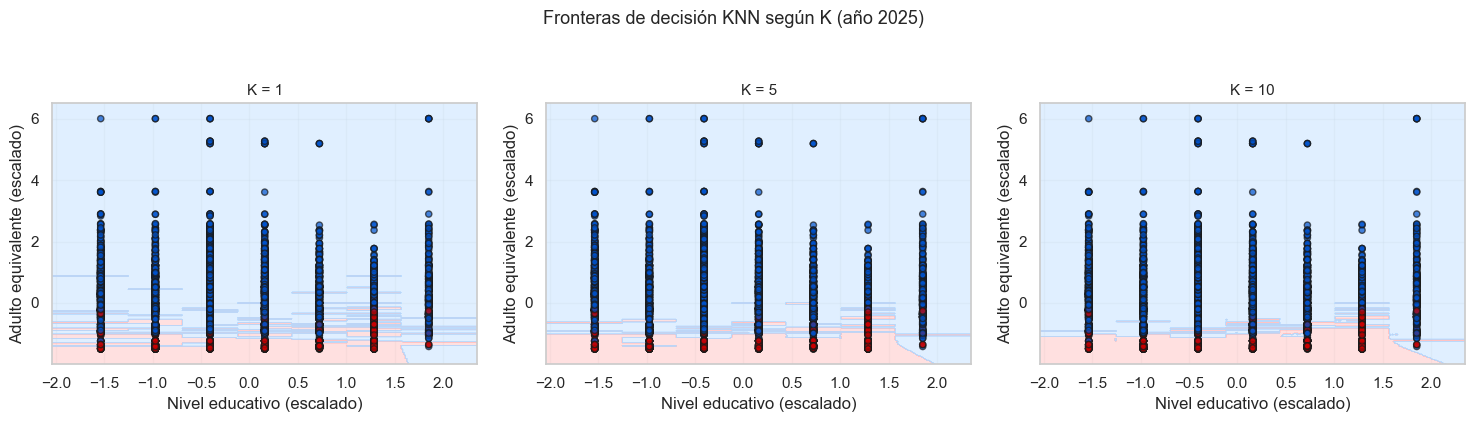

In [60]:
#OPCION A

import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Año y variables a graficar
año = 2025
vars_plot = ["nivel_ed", "ad_equiv_hogar"]

X = splits[año]["X_train"][vars_plot].copy()
y = splits[año]["y_train"].copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Grilla para la frontera
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Paleta de colores
from matplotlib.colors import ListedColormap
cmap_background = ListedColormap(["#ffb3b3", "#b3d9ff"])  # rojo claro / azul claro
cmap_points = ListedColormap(["#cc0000", "#0052cc"])      # rojo / azul

# Gráfico comparativo K = 1, 5, 10
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 10]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=cmap_points, s=20, edgecolor="k", alpha=0.7)
    ax.set_title(f"K = {k}", fontsize=11)
    ax.set_xlabel("Nivel educativo (escalado)")
    ax.set_ylabel("Adulto equivalente (escalado)")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

fig.suptitle(f"Fronteras de decisión KNN según K (año {año})", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()


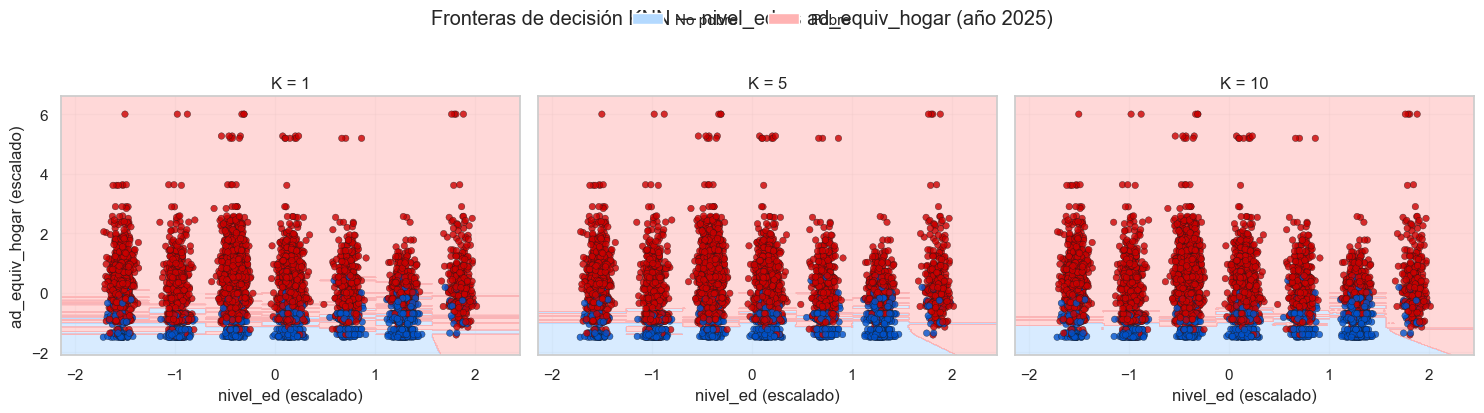

In [61]:
#OPCION B

import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

año = 2025
vars_plot = ["nivel_ed", "ad_equiv_hogar"]  # mismas que venías usando
df = splits[año]["X_train"][vars_plot].dropna().copy()
y  = splits[año]["y_train"].loc[df.index].values

scaler = StandardScaler()
Xz = scaler.fit_transform(df.values)

# jitter suave SOLO para graficar (no para entrenar)
rng = np.random.default_rng(0)
Xz_plot = Xz.copy()
Xz_plot[:,0] += rng.normal(0, 0.06, size=len(Xz_plot))  # jitter en x

# grilla
pad=0.6
xx, yy = np.meshgrid(
    np.linspace(Xz[:,0].min()-pad, Xz[:,0].max()+pad, 400),
    np.linspace(Xz[:,1].min()-pad, Xz[:,1].max()+pad, 400)
)

cmap_bg  = ListedColormap(["#b3d9ff","#ffb3b3"])
cmap_pts = ListedColormap(["#0052cc","#cc0000"])

fig, axes = plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
for ax, k in zip(axes,[1,5,10]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xz, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
    ax.scatter(Xz_plot[:,0], Xz_plot[:,1], c=y, cmap=cmap_pts, s=22, edgecolor="k", lw=0.3, alpha=0.8)
    ax.set_title(f"K = {k}"); ax.grid(alpha=.2)
    ax.set_xlabel(f"{vars_plot[0]} (escalado)")
axes[0].set_ylabel(f"{vars_plot[1]} (escalado)")
fig.legend([Patch(facecolor="#b3d9ff"), Patch(facecolor="#ffb3b3")],
           ["No pobre","Pobre"], loc="upper center", ncol=2, frameon=False)
fig.suptitle(f"Fronteras de decisión KNN — {vars_plot[0]} vs {vars_plot[1]} (año {año})", y=1.03)
plt.tight_layout(); plt.show()

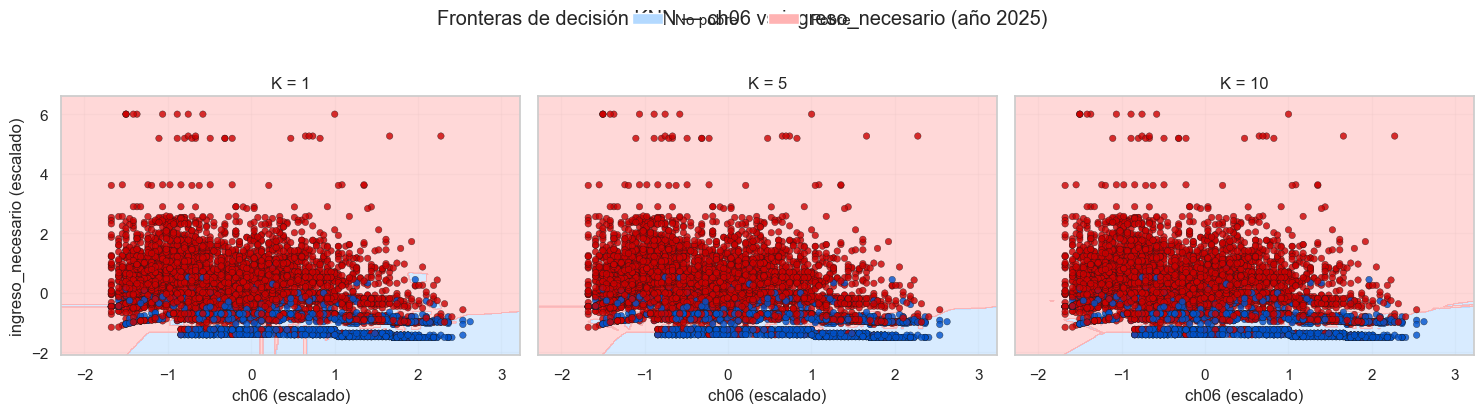

In [62]:
#OPCION C

# reemplazá por 2 variables continuas de tu base
vars_plot = ["ch06", "ingreso_necesario"]  # ejemplo continuo + continuo

df = splits[año]["X_train"][vars_plot].dropna().copy()
y  = splits[año]["y_train"].loc[df.index].values

scaler = StandardScaler()
Xz = scaler.fit_transform(df.values)

pad=0.6
xx, yy = np.meshgrid(
    np.linspace(Xz[:,0].min()-pad, Xz[:,0].max()+pad, 400),
    np.linspace(Xz[:,1].min()-pad, Xz[:,1].max()+pad, 400)
)

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
cmap_bg  = ListedColormap(["#b3d9ff","#ffb3b3"])
cmap_pts = ListedColormap(["#0052cc","#cc0000"])

fig, axes = plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
for ax, k in zip(axes,[1,5,10]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xz, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
    ax.scatter(Xz[:,0], Xz[:,1], c=y, cmap=cmap_pts, s=22, edgecolor="k", lw=0.3, alpha=0.8)
    ax.set_title(f"K = {k}"); ax.grid(alpha=.2)
    ax.set_xlabel(f"{vars_plot[0]} (escalado)")
axes[0].set_ylabel(f"{vars_plot[1]} (escalado)")
fig.legend([Patch(facecolor="#b3d9ff"), Patch(facecolor="#ffb3b3")],
           ["No pobre","Pobre"], loc="upper center", ncol=2, frameon=False)
fig.suptitle(f"Fronteras de decisión KNN — {vars_plot[0]} vs {vars_plot[1]} (año {año})", y=1.03)
plt.tight_layout(); plt.show()

### Ejercicio 7

/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  war

,K,Accuracy_mean,Accuracy_std
0,1,0.846146,0.006062
1,3,0.864347,0.010597
2,5,0.873769,0.009803
3,7,0.878051,0.008072
4,9,0.877837,0.008150
5,11,0.877409,0.006830
6,13,0.878480,0.006178
7,15,0.877302,0.006967
8,20,0.878480,0.005010
9,25,0.880621,0.005676


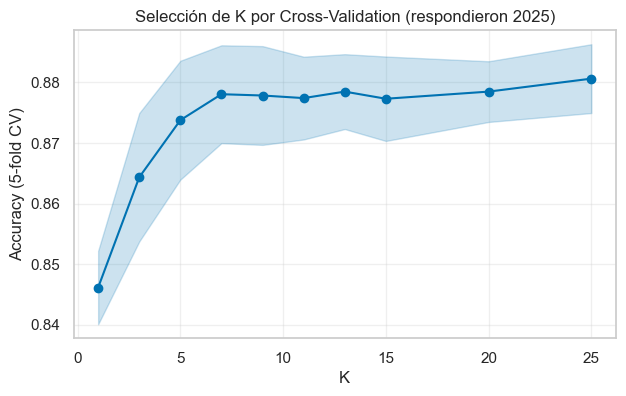

K óptimo por 5-fold CV: 25


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['ano4', 'ch04', 'ch06',
                                                   'ch07', 'ch08', 'nivel_ed',
                                                   'estado', 'cat_inac', 'ch10',
                                                   'ch03', 'ch14', 'ch15',
                                                   'pp02e', 'pp02i', 'ch09',
                                                   'nivel ed', 'adulto_equiv',
                                                   'ad_equiv_hogar',
                                                   'ingreso_necesario']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['codusu', 'sexo'])])),
                ('knn', KNeighborsClassifier(n_neighbors=25))])

In [63]:
# === IMPORTS NECESARIOS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# === 1) Datos: respondieron_2025 ===
# (si no está en memoria, filtralo antes)
# respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

y = respondieron_2025["pobre"].astype(int).copy()
X = respondieron_2025.drop(columns=["pobre", "ingreso", "ipcf", "intercepto"], errors="ignore").copy()

# === 2) Identificar tipos de variables ===
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# eliminar categóricas con cardinalidad excesiva (IDs, códigos únicos, etc.)
high_card = [c for c in cat_cols if X[c].nunique() > 0.5 * len(X)]
cat_cols = [c for c in cat_cols if c not in high_card]

# === 3) Preprocesamiento ===
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop"
)

# === 4) Búsqueda de K por 5-fold CV ===
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 20, 25]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

cv_stats = []
for k in k_values:
    pipe = Pipeline([
        ("prep", pre),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    cv_stats.append({
        "K": k,
        "Accuracy_mean": scores.mean(),
        "Accuracy_std": scores.std()
    })

# mostrar tabla completa sin recorte
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

display(cv_df)


# === 5) Gráfico Accuracy vs K ===
plt.figure(figsize=(7, 4))
plt.plot(cv_df["K"], cv_df["Accuracy_mean"], marker="o", color="#0072B2")
plt.fill_between(
    cv_df["K"],
    cv_df["Accuracy_mean"] - cv_df["Accuracy_std"],
    cv_df["Accuracy_mean"] + cv_df["Accuracy_std"],
    color="#0072B2", alpha=0.2
)
plt.xlabel("K")
plt.ylabel("Accuracy (5-fold CV)")
plt.title("Selección de K por Cross-Validation (respondieron 2025)")
plt.grid(True, alpha=0.3)
plt.show()

# === 6) K óptimo ===
k_opt = int(cv_df.loc[cv_df["Accuracy_mean"].idxmax(), "K"])
print(f"K óptimo por 5-fold CV: {k_opt}")

# === 7) Entrenar modelo final ===
knn_cv = Pipeline([
    ("prep", pre),
    ("knn", KNeighborsClassifier(n_neighbors=k_opt))
])
knn_cv.fit(X, y)

## **D. Desempeño de modelos, elección y predicción afuera de la muestra**

### Ejercicio 8

/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


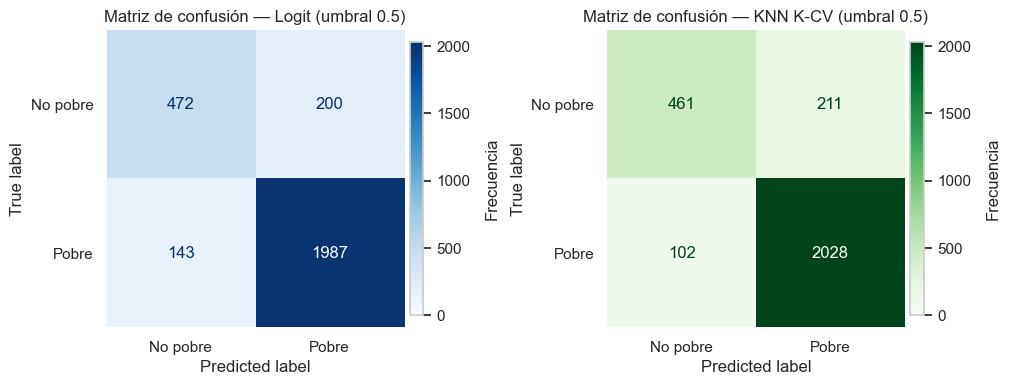

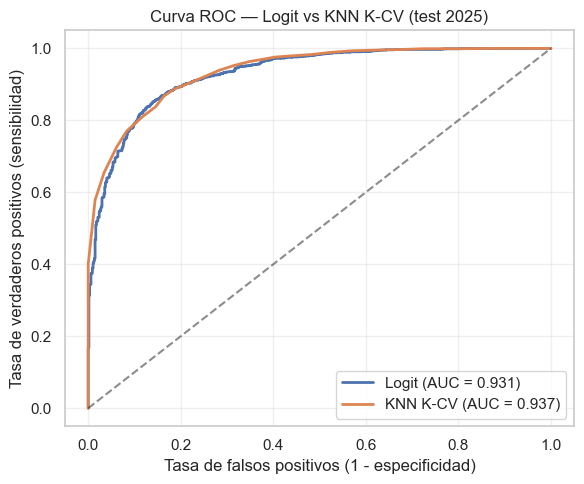

Métricas en test (umbral 0.5)


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Logit,0.8776,0.9086,0.9329,0.9205,0.9305
1,KNN K-CV,0.8883,0.9058,0.9521,0.9284,0.9369


In [64]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# ---------- helper para armar dummies igual que en el entrenamiento ----------
def build_X_with_dummies(df, drop_income_cols=True, ref_cols=None):
    X = df.copy()
    if drop_income_cols:
        forbid = {"pobre","ipcf","itf","intercepto"}
        extra = [c for c in X.columns if "ingreso" in c.lower()]
        X = X.drop(columns=list(forbid)+extra, errors="ignore")

    num = X.select_dtypes(include=np.number).copy()
    cat = X.select_dtypes(exclude=np.number).copy()
    if not num.empty: num = num.fillna(num.median())
    if not cat.empty: cat = cat.fillna(cat.mode().iloc[0])

    Xd = pd.get_dummies(pd.concat([num, cat], axis=1), drop_first=True)
    if ref_cols is not None:
        Xd = Xd.reindex(columns=ref_cols, fill_value=0)
    Xd = sm.add_constant(Xd, has_constant='add')  # agrega 'const'
    return Xd

# ========== 1) Datos de test ==========
X_test_raw = splits[2025]["X_test"].copy()
y_test     = splits[2025]["y_test"].astype(int).copy()

# columnas que usó el logit (sin la constante)
cols_model_x = [c for c in res.params.index if c.lower() not in ["const","intercept","intercepto"]]

# ========== 2) LOGIT: probs y clases (umbral 0.5) ==========
X_test_logit = build_X_with_dummies(X_test_raw, drop_income_cols=True, ref_cols=cols_model_x)
prob_logit   = res.predict(X_test_logit)
pred_logit   = (prob_logit > 0.5).astype(int)

# ========== 3) KNN con K-CV: probs y clases (umbral 0.5) ==========
# (knn_cv es tu pipeline ya entrenado en el inciso 7)
prob_knn = knn_cv.predict_proba(X_test_raw)[:, 1]
pred_knn = (prob_knn > 0.5).astype(int)

# ========== 4) MATRICES DE CONFUSIÓN ==========
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Confusion matrices (mismo rango de color)
cm_logit = confusion_matrix(y_test, pred_logit)
cm_knn   = confusion_matrix(y_test, pred_knn)
vmin, vmax = 0, max(cm_logit.max(), cm_knn.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# --- LOGIT ---
disp1 = ConfusionMatrixDisplay(cm_logit, display_labels=["No pobre", "Pobre"])
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format='d')
axes[0].set_title("Matriz de confusión — Logit (umbral 0.5)")
axes[0].grid(False)
for sp in axes[0].spines.values(): sp.set_visible(False)
disp1.im_.set_clim(vmin=vmin, vmax=vmax)
# Barra azul
cbar1 = fig.colorbar(disp1.im_, ax=axes[0], fraction=0.046, pad=0.02)
cbar1.set_label("Frecuencia", rotation=90, labelpad=10)

# --- KNN ---
disp2 = ConfusionMatrixDisplay(cm_knn, display_labels=["No pobre", "Pobre"])
disp2.plot(ax=axes[1], cmap="Greens", colorbar=False, values_format='d')
axes[1].set_title("Matriz de confusión — KNN K-CV (umbral 0.5)")
axes[1].grid(False)
for sp in axes[1].spines.values(): sp.set_visible(False)
disp2.im_.set_clim(vmin=vmin, vmax=vmax)
# Barra verde
cbar2 = fig.colorbar(disp2.im_, ax=axes[1], fraction=0.046, pad=0.02)
cbar2.set_label("Frecuencia", rotation=90, labelpad=10)

plt.show()

# ========== 5) CURVAS ROC ==========
fpr_logit, tpr_logit, _ = roc_curve(y_test, prob_logit)
fpr_knn,   tpr_knn,   _ = roc_curve(y_test, prob_knn)
auc_logit = roc_auc_score(y_test, prob_logit)
auc_knn   = roc_auc_score(y_test, prob_knn)

plt.figure(figsize=(6,5))
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})", lw=2)
plt.plot(fpr_knn,   tpr_knn,   label=f"KNN K-CV (AUC = {auc_knn:.3f})", lw=2)
plt.plot([0,1],[0,1],"k--",alpha=0.5)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC — Logit vs KNN K-CV (test 2025)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ========== 6) MÉTRICAS (umbral 0.5) ==========
def resumen_metricas(y_true, y_pred, y_prob, nombre):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

tabla = pd.DataFrame([
    resumen_metricas(y_test, pred_logit, prob_logit, "Logit"),
    resumen_metricas(y_test, pred_knn,   prob_knn,   "KNN K-CV")
]).round(4)

print("Métricas en test (umbral 0.5)")
display(tabla)

### Ejercicio 9

No hay que hacer codigo

### Ejercicio 10

In [65]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd

# 1) Filtrar 2025 en ambas bases
resp_2025 = respondieron[respondieron["ano4"] == 2025].copy()
noresp_2025 = norespondieron[norespondieron["ano4"] == 2025].copy()

# 2) Definir X e y en respondieron (sin ingresos)
drop_cols = ["pobre", "ingreso", "ipcf", "intercepto"]
Xr = resp_2025.drop(columns=drop_cols, errors="ignore").copy()
yr = resp_2025["pobre"].astype(int).copy()

# 3) X en norespondieron (mismo drop)
Xn = noresp_2025.drop(columns=drop_cols, errors="ignore").copy()

# 4) Usar SOLO columnas comunes a ambas bases
common_cols = sorted(list(set(Xr.columns) & set(Xn.columns)))
Xr = Xr[common_cols].copy()
Xn = Xn[common_cols].copy()

# 5) Separar tipos sobre la intersección
num_cols = Xr.select_dtypes(include=np.number).columns.tolist()
cat_cols = Xr.select_dtypes(exclude=np.number).columns.tolist()

# (opcional) filtrar categóricas de cardinalidad muy alta
high_card = [c for c in cat_cols if Xr[c].nunique() > 0.5 * len(Xr)]
cat_cols = [c for c in cat_cols if c not in high_card]

# 6) Preprocesamiento idéntico al usado antes
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# 7) Entrenar KNN con el K óptimo que ya tenías (k_opt)
#    Si no tenés k_opt en memoria, podés volver a calcularlo rápidamente.
knn_final = Pipeline([
    ("prep", pre),
    ("knn", KNeighborsClassifier(n_neighbors=int(k_opt)))
])
knn_final.fit(Xr, yr)

# 8) Predecir en norespondieron_2025
pred_n = knn_final.predict(Xn)
noresp_2025["pred_pobre"] = pred_n

# 9) Proporción de no respondientes clasificados como pobres
prop_pobres_pred = noresp_2025["pred_pobre"].mean()
print(f"Proporción de no respondientes clasificados como pobres: {prop_pobres_pred:.3f}")

# 10) (Opcional) tabla de conteos %
conteo = noresp_2025["pred_pobre"].value_counts(normalize=True).mul(100).round(2)
print("\n% por clase predicha en norespondieron 2025:")
print(conteo.rename(index={0: "No pobre", 1: "Pobre"}))

# 11) (Opcional) ver qué columnas se perdieron por no estar en ambas bases
perdidas = sorted(set(resp_2025.columns) - set(common_cols))
print("\nColumnas presentes en respondieron_2025 pero NO en norespondieron_2025 (drop por intersección):")
print(perdidas[:20], "..." if len(perdidas) > 20 else "")

Proporción de no respondientes clasificados como pobres: 0.842

% por clase predicha en norespondieron 2025:
pred_pobre
Pobre       84.2
No pobre    15.8
Name: proportion, dtype: float64

Columnas presentes en respondieron_2025 pero NO en norespondieron_2025 (drop por intersección):
['ad_equiv_hogar', 'adulto_equiv', 'codusu', 'ingreso_necesario', 'ipcf', 'pobre'] 


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
